# Spatial Transcriptomics Analysis Pipeline Part 01

## 🧬 Typical Spatial Transcriptomics Workflow

| Phase | Input Data | Processing Step | Target Output |
| :--- | :--- | :--- | :--- |
| **01. Data Preparation** | Raw FastQ / Tissue Images | Alignment | Count Matrix + Coordinates |
| **02. Processing**| Raw Matrix & Coordinates | QC Filtering & Normalization | Filtered AnnData Object |
| **03. Clustering**| Normalized Matrix | Dimension Reduction & Clustering | Defined Spatial Domains |
| **04. Downstream Analysis**| Spatial Domains | Differential Expression | Spatial Variable Genes |

### Environment Setup

In [1]:
pip install -q scanpy squidpy matplotlib

In [2]:
# pip install scvi-tools cell2location

### Import Libraries

In [3]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


#### Load Datasets

In [4]:
import os

# 1. Clean up and build a clear directory path
!rm -rf data/spatial_breast
os.makedirs("data/spatial_breast", exist_ok=True)

print("Target directory ready. Downloading essential files")

# 10X Genomics file URLs
matrix_url = "https://cf.10xgenomics.com/samples/spatial-exp/1.3.0/Visium_FFPE_Human_Breast_Cancer/Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"
spatial_url = "https://cf.10xgenomics.com/samples/spatial-exp/1.3.0/Visium_FFPE_Human_Breast_Cancer/Visium_FFPE_Human_Breast_Cancer_spatial.tar.gz"

# 2. Download directly to destination using -O to rename files to what Scanpy expects
!wget -q -O data/spatial_breast/filtered_feature_bc_matrix.h5 "{matrix_url}"
!wget -q -O data/spatial_breast/spatial.tar.gz "{spatial_url}"

print("Unpacking tissue coordinate maps and images")
# 3. Decompress the imaging bundle
!tar -xzf data/spatial_breast/spatial.tar.gz -C data/spatial_breast/

# 4. Wipe out the compressed tarball to keep memory clear
!rm -f data/spatial_breast/spatial.tar.gz



📁 Target directory ready. Downloading essential files
Unpacking tissue coordinate maps and images


In [5]:
# Read the local data structure
adata = sc.read_visium(
    path="data/spatial_breast/",
    count_file="filtered_feature_bc_matrix.h5"
)
adata.var_names_make_unique()

print(f"• Total Capture Spots (Observations): {adata.n_obs}")
print(f"• Total Unique Genes Detected: {adata.n_vars}")



/tmp/ipykernel_15085/1055643725.py:2: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


• Total Capture Spots (Observations): 2518
• Total Unique Genes Detected: 17943


In [6]:
# Inspect dataset
adata

AnnData object with n_obs × n_vars = 2518 × 17943
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

## Step 2: Quality Control (QC)

We need to calculate how many genes are expressed per spot and identify if any spots contain abnormally high levels of mitochondrial genes (which usually indicates stressed, ruptured, or dying cells).

In [7]:
# 1. Identify mitochondrial genes (Start with "MT-" in humans)
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# 2. Calculate standard QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

# Check the data structure
print(adata.obs[['total_counts', 'n_genes_by_counts', 'pct_counts_mt']].head())

                    total_counts  n_genes_by_counts  pct_counts_mt
AAACAAGTATCTCCCA-1       21201.0               6327            0.0
AAACACCAATAACTGC-1        5672.0               3184            0.0
AAACAGAGCGACTCCT-1       13042.0               4741            0.0
AAACAGCTTTCAGAAG-1        5527.0               2913            0.0
AAACAGGGTCTATATT-1        4591.0               2572            0.0


### Visualize the QC Data

📊 Plotting global QC distributions...


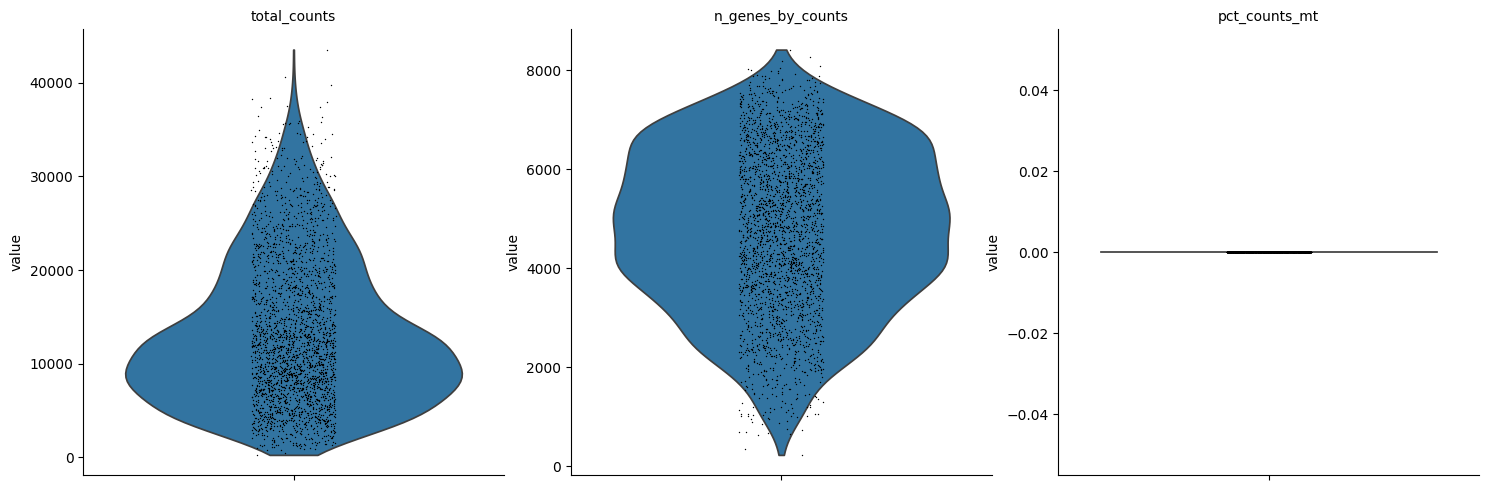

<Figure size 640x480 with 0 Axes>

In [8]:
# ==============================================================================
# 1. VISUALIZE GLOBAL QC DISTRIBUTIONS (Violin Plots)
# ==============================================================================
print("📊 Plotting global QC distributions...")
sc.pl.violin(
    adata,
    keys=["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    multi_panel=True
)

plt.tight_layout()
plt.show()

### Filter Out Low-Quality Data

Filter Out Low-Quality Data
Based on standard Visium thresholds, we will filter out spots with very little genetic information and remove genes that barely show up anywhere in the tissue.

In [9]:
# Spots that have at least 500 unique genes detected
# we may change minimum unique gene (e.g., from 500 to 200)
sc.pp.filter_cells(adata, min_genes=500)

# Genes that are expressed in at least 10 different tissue spots
sc.pp.filter_genes(adata, min_cells=10)

# Filter out spots where mitochondrial expression takes up more than 20% of the total signal
adata = adata[adata.obs['pct_counts_mt'] < 20.0, :].copy()

print(f"Remaining high-quality spots: {adata.n_obs}")
print(f"Remaining high-quality genes: {adata.n_vars}")

Remaining high-quality spots: 2516
Remaining high-quality genes: 14963


## Normalization & Log Transformation

In [10]:
# ==============================================================================
# 1. PRESERVE THE RAW COUNTS
# ==============================================================================
# Many downstream tools (like cell2location/scvi-tools) require un-normalized integers.
# We store the raw matrix in the .raw slot before altering the active matrix.
adata.raw = adata

# ==============================================================================
# 2. TOTAL-COUNT NORMALIZATION
# ==============================================================================

sc.pp.normalize_total(
    adata,
    target_sum=1e4,       # Standardize each spot to represent 10,000 total molecules
    inplace=True
)

# ==============================================================================
# 3. LOG TRANSFORMATION
# ==============================================================================

sc.pp.log1p(adata)       # Computes log(x + 1) to handle zero counts safely


#### Verification: Checking the Shifts in Data
To verify that our normalization successfully flattened out the extreme scale imbalances without deleting biological signals, we can quickly look at the shifted min/max boundaries of our data array:

In [11]:
import numpy as np

# Check a slice of the matrix data values
matrix_sample = adata.X[:5, :5]
if hasattr(matrix_sample, "toarray"):  # Handle sparse matrix translation safely
    matrix_sample = matrix_sample.toarray()

print(np.round(matrix_sample, 3))

[[0.    0.    0.    0.665 0.386]
 [0.    1.017 0.    0.    0.   ]
 [0.    0.569 0.    0.    1.194]
 [0.    0.    0.    0.    0.   ]
 [0.    1.157 0.    0.    0.   ]]


#### How to Read This Matrix
The Rows and Columns: The rows represent 5 individual physical spots on our breast tissue slice, and the columns represent 5 specific genes.

The Zeros (0.): This is a sparse matrix. It is completely normal to see a lot of zeros. It just means those specific genes weren't being actively transcribed in those particular micro-spots when the tissue was captured.

The Decimal Numbers (e.g., 1.017): These are our log-transformed, normalized expression values. Instead of massive, volatile raw read counts (like 4,500 copies vs 1 copy), everything has been elegantly compressed into a tight, manageable scale (typically between 0 and 5).

### Highly Variable Genes (HVGs)

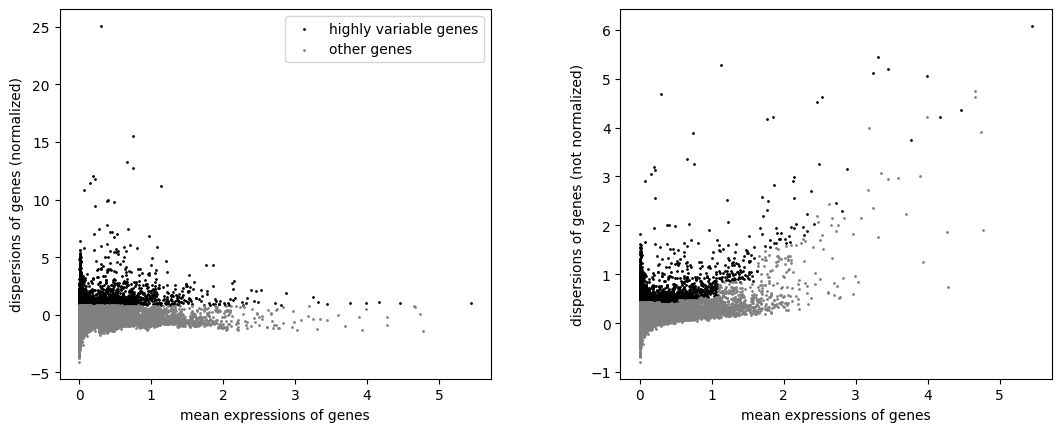

Dataset successfully downsized to highly informative features.
Current matrix dimensions: (2516, 2000) (Spots, Target Genes)


In [12]:
# ==============================================================================
# FEATURE SELECTION: HIGHLY VARIABLE GENES (HVGs)
# ==============================================================================

# For log-normalized data, 'seurat' is the standard, reliable flavor
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,      # Isolate the top 2,000 genes that vary the most
    flavor="seurat"
)

# Visualize the variance spreadsheet mappings
sc.pl.highly_variable_genes(adata)

# Subset the active matrix to ONLY contain these 2,000 key genes
# This dramatically speeds up PCA, UMAP, and prevents Colab Free RAM crashes!
adata = adata[:, adata.var.highly_variable].copy()

print(f"Dataset successfully downsized to highly informative features.")
print(f"Current matrix dimensions: {adata.shape} (Spots, Target Genes)")


#### What to look for in the plot:
When we run this, Scanpy will output a scatter plot tracking dispersion vs. mean expression. The genes highlighted in black are our top variable structural markers. They are the exact genetic levers our pipeline will use in the next step to automatically map out the distinct tumor, stroma, and immune neighborhoods!

In [13]:
# Save with breast-specific name and strict compression
adata.write_h5ad("breast_tumor_hvg_2000.h5ad", compression="gzip")

In [14]:
from google.colab import files

# Force a direct browser download stream
files.download("breast_tumor_hvg_2000.h5ad")